In [29]:
import sys
import subprocess
import requests
from datetime import datetime, timedelta
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from requests.models import PreparedRequest
from urllib.request import Request, urlopen
import numpy as np
from dateutil.relativedelta import relativedelta
import json
import plotly.express as px
import pandas as pd
import pytz
import os
from posixpath import join
import json
import rasterio
import io
from rasterio.io import MemoryFile

import matplotlib
from pathlib import Path

In [14]:
# You will be given a token to access the HCDP API. Add that token here.
hcdp_api_token = ""
# Please input your email address. This will be used for user logging or distributing data packages
email = ""

In [15]:
header = {
  "Authorization": f"Bearer {hcdp_api_token}"
}

In [18]:
class DateRangeResponse:
    def __init__(self, date_range):
        self.date_range = date_range

In [9]:
def getDateRange(data_type, period, production=None, aggregation=None):
    print("Getting a range")
    base_url = "https://api.hcdp.ikewai.org/datasets/date/range?"
    url = f"{base_url}datatype={data_type}&period={period}"

    if production:
        url += f"&production={production}"
    if aggregation:
        url += f"&aggregation={aggregation}"

    try:
        req = Request(url, headers=header)
        with urlopen(req) as response:
            data = json.loads(response.read().decode())

            # Extract only first two values
            date_range = data[:2] if isinstance(data, list) else list(data.values())[:2]

            # Prepare JSON response
            response_object = DateRangeResponse(date_range)
            json_data = json.dumps(response_object.__dict__, indent=4)

            # Define filename based on request parameters
            file_name = f"data_{data_type}_{period}"
            if production:
                file_name += f"_{production}"
            if aggregation:
                file_name += f"_{aggregation}"
            file_name += ".json"

            unity_data_path = os.path.join(os.getcwd(), "RangeData")

            os.makedirs(unity_data_path, exist_ok=True)

            file_path = os.path.join(unity_data_path, file_name)

            if not os.path.exists(file_path):
                with open(file_path, "w") as json_file:
                    json_file.write(json_data)
                print(f"Data saved to {file_path}")
            else:
                print(f"File already exitst: {file_path}")
            
            return file_path

    except Exception as e:
        print(json.dumps({"error": str(e)}))
        return None

In [19]:
getDateRange("temperature", "day", None, "mean")
getDateRange("temperature", "month", None, "mean")
getDateRange("rainfall", "day", "new", None)
getDateRange("rainfall", "month", "new", None)
getDateRange("rainfall", "month", "legacy", None)
getDateRange("relative_humidity", "day", None, None)

Getting a range
File already exitst: c:\Users\Aaron McLean\ccsvi-dashboard\public\data\HCDP_API\RangeData\data_temperature_day_mean.json
Getting a range
File already exitst: c:\Users\Aaron McLean\ccsvi-dashboard\public\data\HCDP_API\RangeData\data_temperature_month_mean.json
Getting a range
File already exitst: c:\Users\Aaron McLean\ccsvi-dashboard\public\data\HCDP_API\RangeData\data_rainfall_day_new.json
Getting a range
File already exitst: c:\Users\Aaron McLean\ccsvi-dashboard\public\data\HCDP_API\RangeData\data_rainfall_month_new.json
Getting a range
File already exitst: c:\Users\Aaron McLean\ccsvi-dashboard\public\data\HCDP_API\RangeData\data_rainfall_month_legacy.json
Getting a range
File already exitst: c:\Users\Aaron McLean\ccsvi-dashboard\public\data\HCDP_API\RangeData\data_relative_humidity_day.json


'c:\\Users\\Aaron McLean\\ccsvi-dashboard\\public\\data\\HCDP_API\\RangeData\\data_relative_humidity_day.json'

In [34]:
import json

BASE_DIR = os.getcwd()

# Describe each file + metadata you want to attach
files_config = [
    {
        "path": os.path.join(BASE_DIR, "RangeData", "data_temperature_day_mean.json"),
        "data_type": "temperature",
        "period": "day",
        "aggregation": "mean"
    },
    {
        "path": os.path.join(BASE_DIR, "RangeData", "data_temperature_month_mean.json"),
        "data_type": "temperature",
        "period": "month",
        "aggregation": "mean"
    },
    {
        "path": os.path.join(BASE_DIR, "RangeData", "data_rainfall_day_new.json"),
        "data_type": "temperature",
        "period": "day",
        "production": "new"
    },
    {
        "path": os.path.join(BASE_DIR, "RangeData", "data_rainfall_month_legacy.json"),
        "data_type": "temperature",
        "period": "month",
        "production": "legacy"
    },
    {
        "path": os.path.join(BASE_DIR, "RangeData", "data_rainfall_month_new.json"),
        "data_type": "temperature",
        "period": "month",
        "production": "new"
    },
    {
        "path": os.path.join(BASE_DIR, "RangeData", "data_relative_humidity_day.json"),
        "data_type": "temperature",
        "period": "day"
    },
]

combined = []


for config in files_config:
    with open(config["path"], "r") as f:
        data = json.load(f)

    entry = {
        "data_type": config["data_type"],
        "period": config["period"],
        "date_range": data["date_range"]
    }

    # optional fields
    if "production" in config:
        entry["production"] = config["production"]

    if "aggregation" in config:
        entry["aggregation"] = config["aggregation"]

    combined.append(entry)

# write output
with open("date_Range_Combined.json", "w") as f:
    json.dump(combined, f, indent=4)

In [4]:
output_folder = os.getcwd()
tif_path = os.path.join(output_folder, "output.tif")

In [37]:

def display_raster(
    params,
    title,
    cmap=plt.cm.viridis.reversed(),
    nodata_color="#f0f0f000",
    save_png_path=None,
    save_tif_path=None
):
    raster_ep = "/raster"
    api_base_url = "https://api.hcdp.ikewai.org"

    url = f"{api_base_url}{raster_ep}"

    # Build URL with params
    url_constructor = PreparedRequest()
    url_constructor.prepare_url(url, params)
    full_url = url_constructor.url
    
    print("Request URL:", full_url)

    req = Request(full_url, headers=header)

    with urlopen(req) as response:
        raw_data = response.read()

    # ✅ Save GeoTIFF (raw bytes)
    if save_tif_path:
        with open(save_tif_path, "wb") as f:
            f.write(raw_data)
        print("Saved GeoTIFF:", save_tif_path)

    # Convert bytes → readable stream for matplotlib
    raster_stream = io.BytesIO(raw_data)

    # Read TIFF into array
    img = plt.imread(raster_stream, format="tiff")

    # Mask nodata (basic assumption)
    masked = np.ma.masked_equal(img, img[0][0])

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title)

    cmap.set_bad(nodata_color)

    imgplot = ax.imshow(masked[:, :, 0], cmap=cmap)
    fig.colorbar(imgplot, ax=ax)

    # Save PNG


    plt.show()

Request URL: https://api.hcdp.ikewai.org/raster?datatype=temperature&aggregation=mean&period=day&date=2024-01-01&extent=statewide
Saved GeoTIFF: c:\Users\Aaron McLean\ccsvi-dashboard\public\data\HCDP_API\output.tif


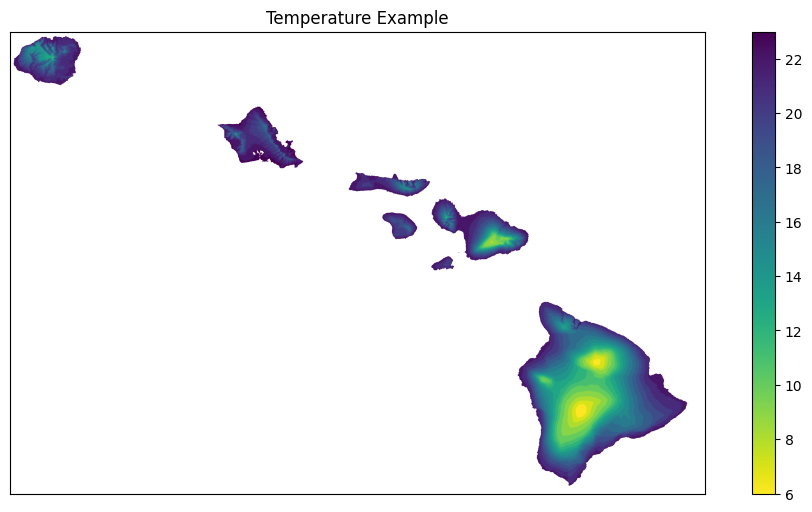

In [38]:
params = {
    "datatype": "temperature",
    "aggregation": "mean",
    "period": "day",
    "date": "2024-01-01",
    "extent": "statewide"
}


display_raster(
    params,
    title="Temperature Example",
    save_tif_path=tif_path
)